In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as pyt

In [2]:
data = {
    "City": ["Tokyo", "New York", "London", "Paris"],
    "Latitude": [35.6895, 40.7128, 51.5074, 48.8566],
    "Longitude": [139.6917, -74.0060, -0.1278, 2.3522],
}

df = pd.DataFrame(data)

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude))
gdf

,City,Latitude,Longitude,geometry
0,Tokyo,35.6895,139.6917,POINT (139.6917 35.6895)
1,New York,40.7128,-74.0060,POINT (-74.006 40.7128)
2,London,51.5074,-0.1278,POINT (-0.1278 51.5074)
3,Paris,48.8566,2.3522,POINT (2.3522 48.8566)


In [3]:
url = "https://github.com/opengeos/datasets/releases/download/vector/nybb.geojson"
gdf = gpd.read_file(url)
gdf.head()


,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


In [4]:
output_file = "nyc_buroughs.gpkg"
gdf.to_file(output_file)

In [5]:
gdf_4326 = gdf.to_crs(epsg=4326)
print(f"Reprojected CRS: {gdf_4326.crs}")
gdf_4326.head()

Reprojected CRS: EPSG:4326


,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((-74.05051 40.56642, -74.05047 ..."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((-73.83668 40.59495, -73.83678 ..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((-73.86706 40.58209, -73.86769 ..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((-74.01093 40.68449, -74.01193 ..."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((-73.89681 40.79581, -73.89694 ..."


In [6]:
gdf = gdf.to_crs("EPSG:3857")
gdf = gdf.set_index("BoroName")

In [7]:
gdf["area"] = gdf.area
gdf["area_km2"] = gdf['area'] / 1_000_000
gdf[["area", "area_km2"]].sort_values("area_km2", ascending=False)
gdf["boundary"] = gdf.boundary
gdf["centroid"] = gdf.centroid
gdf[["boundary", "centroid"]].head()

,boundary,centroid
BoroName,,
Staten Island,"MULTILINESTRING ((-8243264.851 4948597.836, -8...",POINT (-8254713.541 4950718.061)
Queens,"MULTILINESTRING ((-8219461.925 4952778.732, -8...",POINT (-8217436.751 4969318.726)
Brooklyn,"MULTILINESTRING ((-8222843.672 4950893.793, -8...",POINT (-8231817.467 4960085.273)
Manhattan,"MULTILINESTRING ((-8238858.864 4965915.024, -8...",POINT (-8233984.803 4979551.765)
Bronx,"MULTILINESTRING ((-8226155.13 4982269.949, -82...",POINT (-8222783.631 4990631.242)


In [10]:
manhattan_centroid = gdf.loc["Manhattan", "centroid"]
gdf["distance_to_manhattan"] = gdf["centroid"].distance(manhattan_centroid)
gdf["distance_to_manhattan_km"] = gdf['distance_to_manhattan'] / 1000
gdf[["distance_to_manhattan_km"]].sort_values("distance_to_manhattan_km")
mean_distance = gdf["distance_to_manhattan_km"].mean()
max_distance = gdf["distance_to_manhattan_km"].max()
total_area = gdf["area_km2"].sum()

print(f"Mean distance to Manhattan: {mean_distance:.2f} km")
print(f"Maximum distance to Manhattan: {max_distance:.2f} km")
print(f"Total NYC area: {total_area:.2f} km²")

Mean distance to Manhattan: 18.06 km
Maximum distance to Manhattan: 35.51 km
Total NYC area: 1363.75 km²


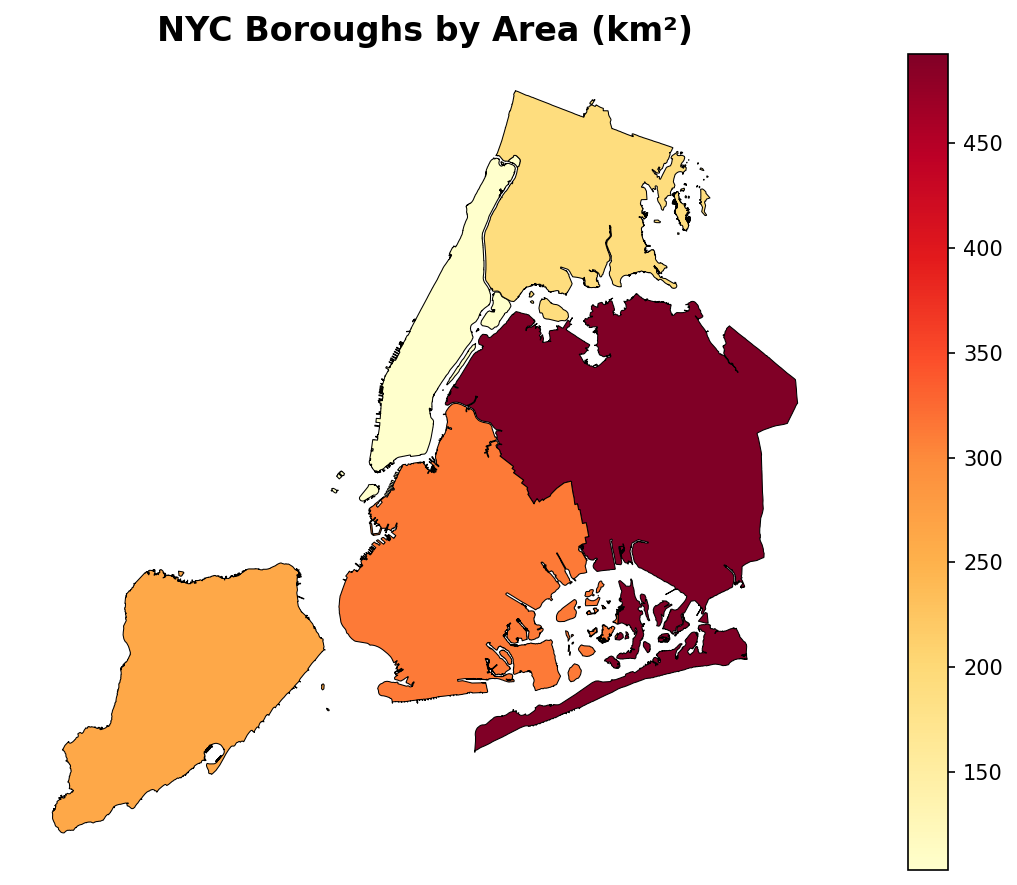

In [11]:
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 150

fig, ax = plt.subplots(figsize=(10, 6))

gdf.plot(
    column="area_km2",
    ax=ax,
    legend=True,
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.5
)

plt.title("NYC Boroughs by Area (km²)", fontsize=16, fontweight="bold")
plt.axis("off") # Remove coordinate axes for cleaner appearance
plt.tight_layout()
plt.show()